In [ ]:
import kagglehub
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import glob
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from collections import Counter
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [ ]:
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
train_dir ='/kaggle/input/chest-xray-pneumonia/chest_xray/train'
val_dir ='/kaggle/input/chest-xray-pneumonia/chest_xray/val'
test_dir ='/kaggle/input/chest-xray-pneumonia/chest_xray/test'

In [ ]:
def load_data(root_dir,img_size=(128,128)):
  img_paths=glob.glob(os.path.join(root_dir,'*/*.jpeg'))

  images=[]
  labels=[]

  for img_path in tqdm(img_paths,desc='processing..'):
    image=cv2.imread(img_path)
    image=cv2.resize(image,img_size)
    image=image.astype('float') /255.0
    label=os.path.basename(os.path.dirname(img_path))
    images.append(image)
    labels.append(label)
  return np.array(images),np.array(labels)

In [ ]:
X_train , y_train=load_data(train_dir)
X_val , y_val=load_data(val_dir)
X_test , y_test=load_data(test_dir)

processing..: 100%|██████████| 624/624 [00:08<00:00, 69.91it/s]


In [ ]:
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)
print(X_test.shape,y_test.shape)

(5216, 64, 64, 3) (5216,)
(16, 64, 64, 3) (16,)
(624, 64, 64, 3) (624,)


In [ ]:
print(y_train[0:5],y_train[-5:-1])

['PNEUMONIA' 'PNEUMONIA' 'PNEUMONIA' 'PNEUMONIA' 'PNEUMONIA'] ['NORMAL' 'NORMAL' 'NORMAL' 'NORMAL']


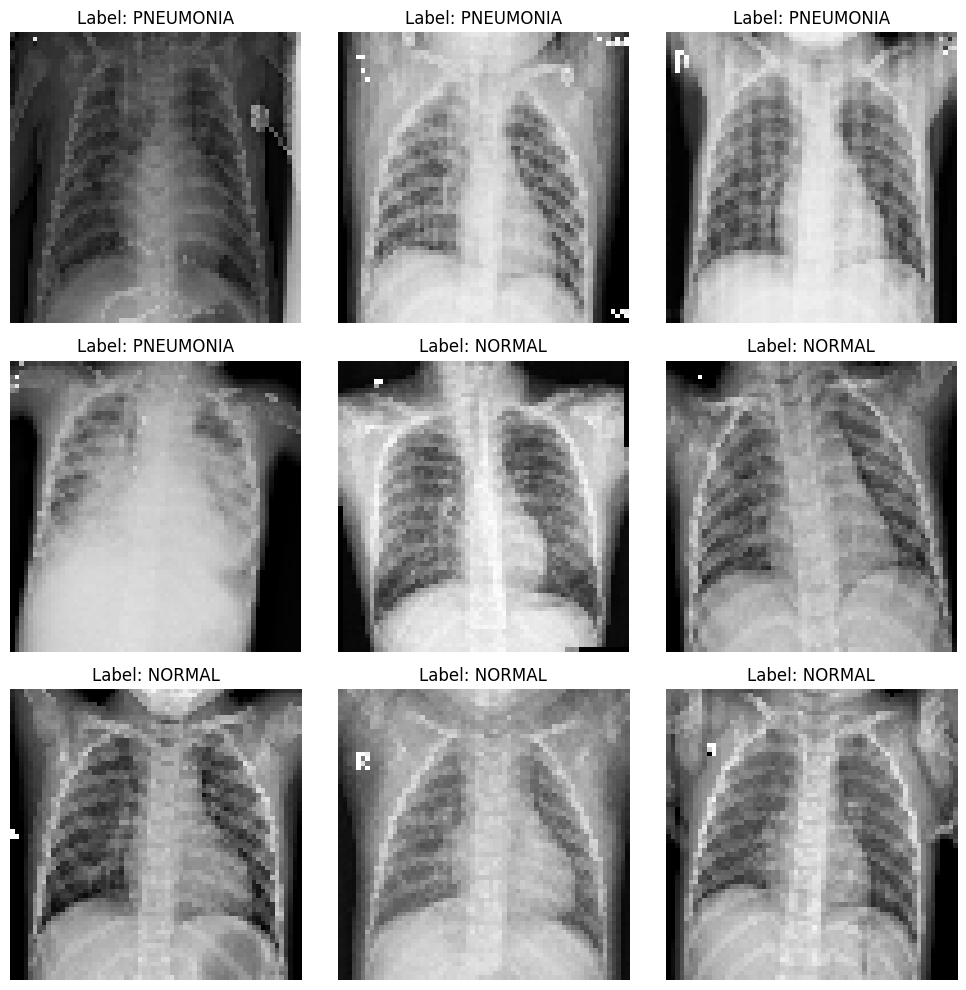

In [ ]:
fig, axs = plt.subplots(3, 3, figsize=(10, 10))
for i in range(4):
    row = i // 3
    col = i % 3
    axs[row, col].imshow(X_train[i], cmap='gray')
    axs[row, col].set_title(f"Label: {y_train[i]}")
    axs[row, col].axis('off')

last_indices = range(len(X_train) - 5, len(X_train))
for j, idx in enumerate(last_indices, start=4):
    row = j // 3
    col = j % 3
    axs[row, col].imshow(X_train[idx], cmap='gray')
    axs[row, col].set_title(f"Label: {y_train[idx]}")
    axs[row, col].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
print("Train labels:", np.unique(y_train))
print("Val labels:", np.unique(y_val))
print("Test labels:", np.unique(y_test))

Train labels: ['NORMAL' 'PNEUMONIA']
Val labels: ['NORMAL' 'PNEUMONIA']
Test labels: ['NORMAL' 'PNEUMONIA']


In [ ]:
label_encoder = LabelEncoder()
y_train_encode = label_encoder.fit_transform(y_train)
y_val_encode= label_encoder.transform(y_val)
y_test_encode = label_encoder.transform(y_test)

In [ ]:
print(y_train_encode[0:5],y_train_encode[-5:-1])
print(y_train_encode.shape)

[1 1 1 1 1] [0 0 0 0]
(5216,)


In [ ]:
counter=Counter(y_train)
print(counter)

Counter({np.str_('PNEUMONIA'): 3875, np.str_('NORMAL'): 1341})


In [ ]:
most_common_label=max(y_train,key=counter.get)
print(most_common_label)

PNEUMONIA


In [ ]:
model=Sequential(
 [
     Conv2D(32,(3,3),activation='relu',padding='valid',strides=2,input_shape=(128,128,3)),
     Conv2D(64,(3,3),activation='relu'),
     MaxPooling2D((2,2),strides=2),
     Flatten(),
     Dense(64,activation='relu'),
     Dense(64,activation='relu'),
     Dense(1, activation='sigmoid')
 ]
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 63, 63, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,710,081 (14.15 MB)

 Trainable params: 3,710,081 (14.15 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history=model.fit(X_train, y_train_encode, epochs=10, batch_size=32, validation_data=(X_val,y_val_encode))

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8451 - loss: 0.3389 - val_accuracy: 0.8125 - val_loss: 0.2841
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9644 - loss: 0.0927 - val_accuracy: 0.8125 - val_loss: 0.3656
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9739 - loss: 0.0737 - val_accuracy: 0.8750 - val_loss: 0.2906
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9805 - loss: 0.0533 - val_accuracy: 0.8750 - val_loss: 0.2478
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9855 - loss: 0.0420 - val_accuracy: 1.0000 - val_loss: 0.0230
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9898 - loss: 0.0328 - val_accuracy: 1.0000 - val_loss: 0.0281
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9887 - loss: 0.0286 - val_accuracy: 0.8750 - val_loss: 0.1542
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9950 - loss: 0.0152 - val_accu

In [ ]:
loss , accuracy=model.evaluate(X_test,y_test_encode)
print('Test_loss= ',loss)
print('Test_accuracy= ',accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9189 - loss: 0.6843
Test_loss=  2.32665753364563
Test_accuracy=  0.7339743375778198


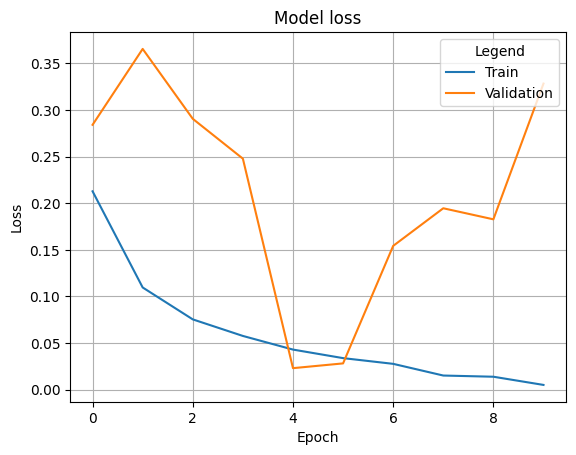

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model loss")
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(["Train", "Validation"], loc='upper right', fontsize='medium', title="Legend")
plt.grid(True)
plt.show()

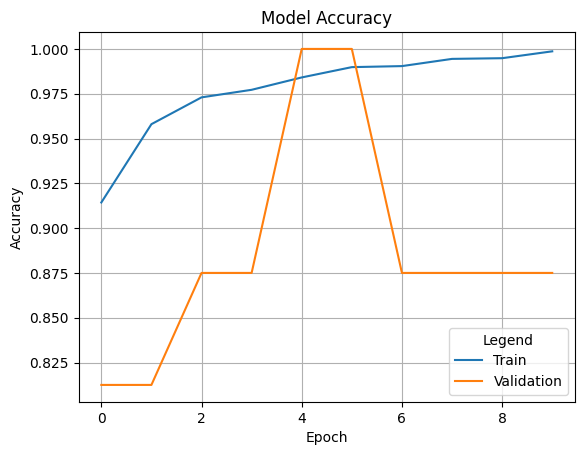

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(["Train", "Validation"], loc='lower right', fontsize='medium', title="Legend")
plt.grid(True)
plt.show()

In [ ]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int").flatten()
print("Predicted labels:", y_pred[:10])
print("Actual labels:   ", y_test_encode[:10])

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
Predicted labels: [1 1 1 1 1 1 1 1 1 1]
Actual labels:    [1 1 1 1 1 1 1 1 1 1]


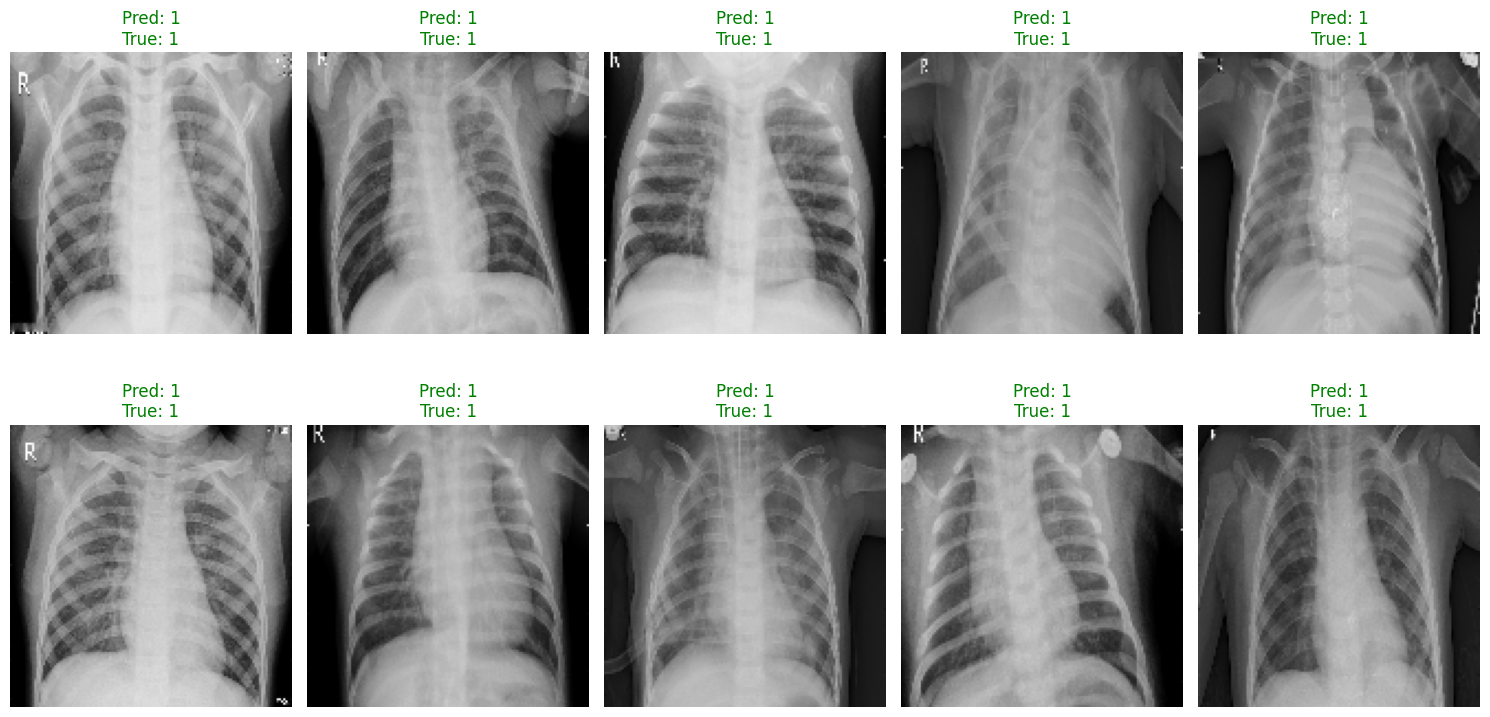

In [ ]:
plt.figure(figsize=(15, 8))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i])

    correct = y_pred[i] == y_test_encode[i]
    color = 'green' if correct else 'red'

    plt.title(f"Pred: {y_pred[i]}\nTrue: {y_test_encode[i]}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
print(classification_report(y_test_encode, y_pred, target_names=["Normal", "Pneumonia"]))

              precision    recall  f1-score   support

      Normal       0.95      0.31      0.46       234
   Pneumonia       0.70      0.99      0.82       390

    accuracy                           0.73       624
   macro avg       0.83      0.65      0.64       624
weighted avg       0.80      0.73      0.69       624



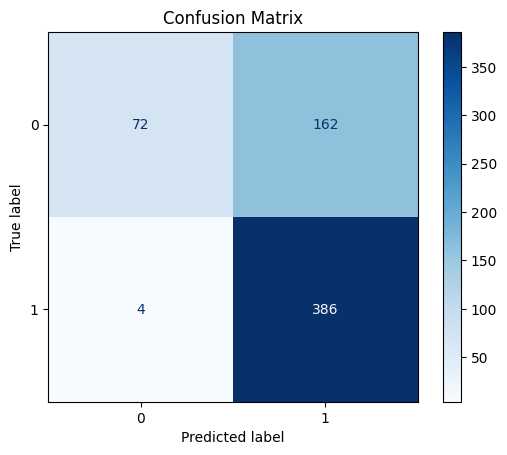

In [ ]:
cm = confusion_matrix(y_test_encode, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
datagen = ImageDataGenerator(
        featurewise_center=False,
        samplewise_center=False,
        featurewise_std_normalization=False,
        samplewise_std_normalization=False,
        zca_whitening=False,
        rotation_range = 30,
        zoom_range = 0.2,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip = True,
        vertical_flip=False)
datagen.fit(X_train)

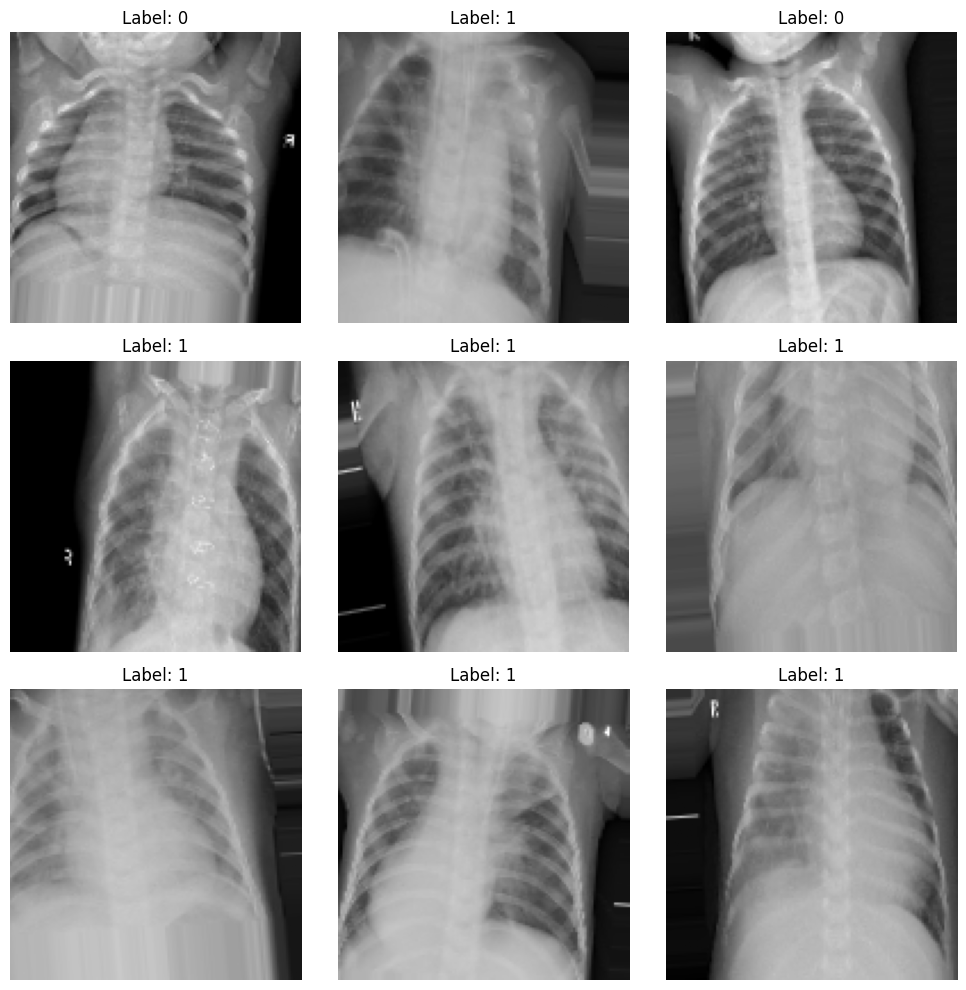

In [ ]:
# augmented_iter = datagen.flow(X_train, y_train_encode, batch_size=9)
# images, labels = next(augmented_iter)

# plt.figure(figsize=(10, 10))
# for i in range(9):
#     plt.subplot(3, 3, i + 1)
#     plt.imshow(images[i])
#     plt.axis('off')
#     plt.title("Label: {}".format(labels[i]))
# plt.tight_layout()
# plt.show()

In [ ]:
reduction = ReduceLROnPlateau(monitor='val_accuracy', patience = 2, verbose=1,factor=0.3, min_lr=0.000001)

In [ ]:
history2 = model.fit(datagen.flow(X_train, y_train_encode, batch_size=32),epochs=15,validation_data=(X_val, y_val_encode),callbacks = [reduction])

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 21s 125ms/step - accuracy: 0.9524 - loss: 0.1225 - val_accuracy: 0.8125 - val_loss: 0.2695 - learning_rate: 0.0010
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 21s 128ms/step - accuracy: 0.9497 - loss: 0.1384 - val_accuracy: 0.8125 - val_loss: 0.3130 - learning_rate: 0.0010
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.9480 - loss: 0.1350
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
163/163 ━━━━━━━━━━━━━━━━━━━━ 19s 117ms/step - accuracy: 0.9480 - loss: 0.1350 - val_accuracy: 0.7500 - val_loss: 0.4417 - learning_rate: 0.0010
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 20s 124ms/step - accuracy: 0.9552 - loss: 0.1214 - val_accuracy: 0.8125 - val_loss: 0.2546 - learning_rate: 3.0000e-04
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 21s 126ms/step - accuracy: 0.9562 - loss: 0.1141 - val_accuracy: 0.9375 - val_loss: 0.1800 - learning_rate: 3.0000e-04
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 19s 116ms/step - accurac

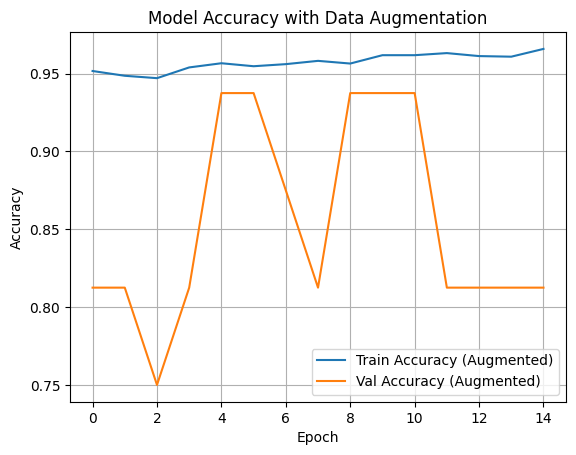

In [ ]:
plt.plot(history2.history['accuracy'], label='Train Accuracy (Augmented)')
plt.plot(history2.history['val_accuracy'], label='Val Accuracy (Augmented)')
plt.title('Model Accuracy with Data Augmentation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

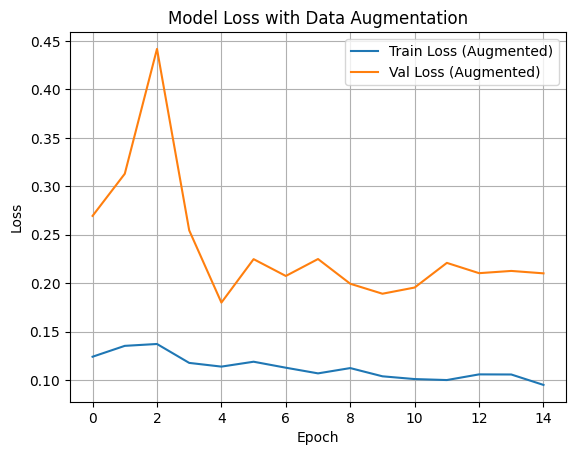

In [ ]:
plt.plot(history2.history['loss'], label='Train Loss (Augmented)')
plt.plot(history2.history['val_loss'], label='Val Loss (Augmented)')
plt.title('Model Loss with Data Augmentation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_encode, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.9054
Test Loss: 0.2991


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


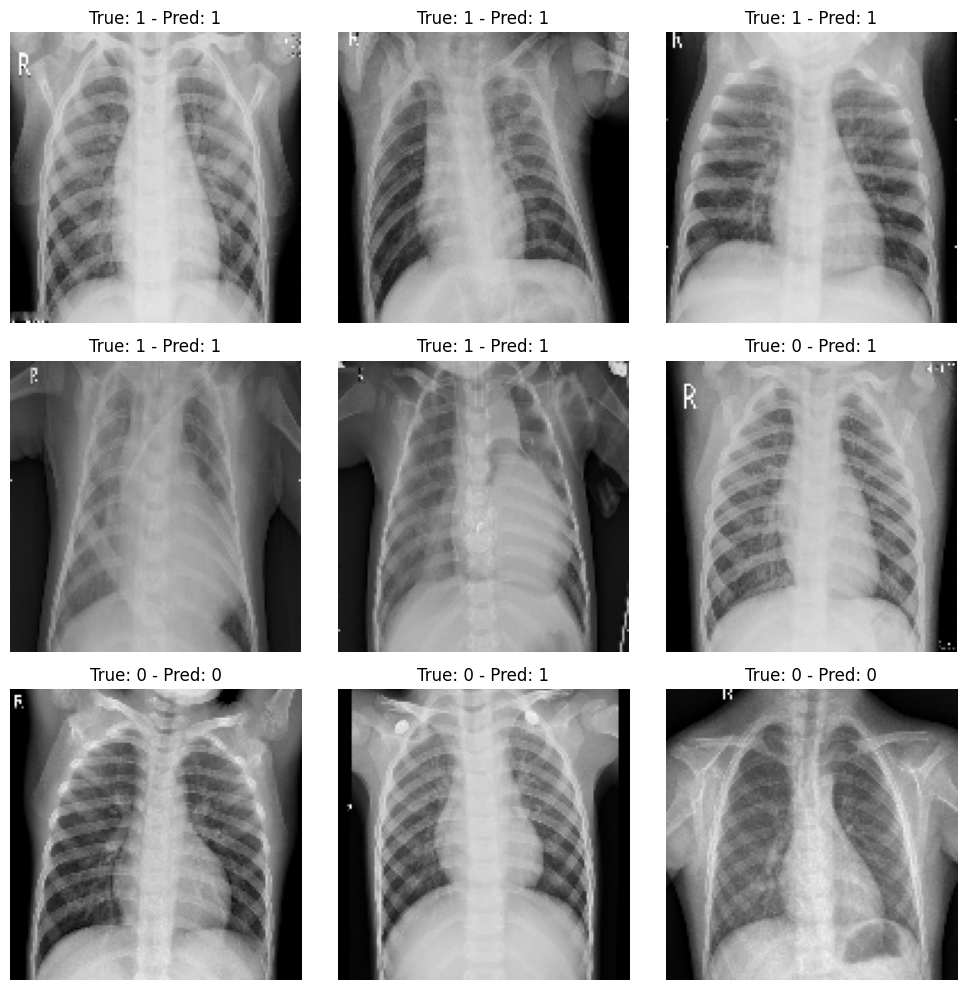

In [ ]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int").flatten()

start_indices = list(range(5))
end_indices = list(range(len(X_test) - 4, len(X_test)))
mixed_indices = start_indices + end_indices

plt.figure(figsize=(10, 10))
for i, idx in enumerate(mixed_indices):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[idx])
    plt.axis('off')
    true_label = y_test_encode[idx]
    pred_label = y_pred[idx]
    plt.title(f"True: {true_label} - Pred: {pred_label}")
plt.tight_layout()
plt.show()

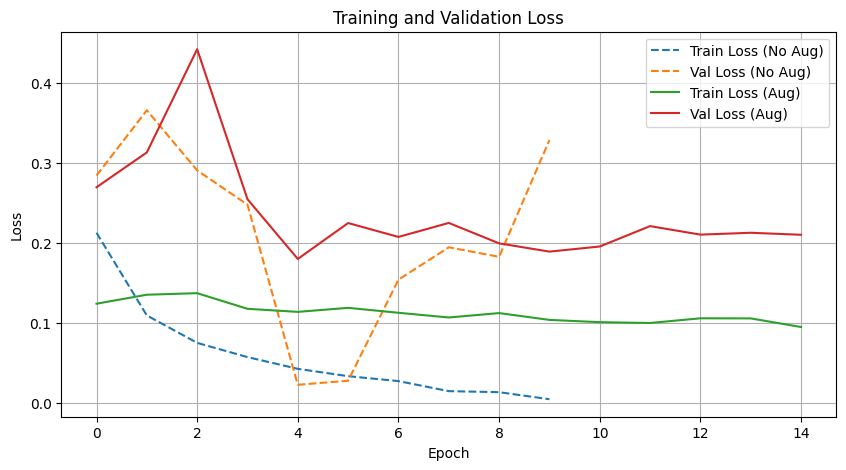

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss (No Aug)', linestyle='--')
plt.plot(history.history['val_loss'], label='Val Loss (No Aug)', linestyle='--')
plt.plot(history2.history['loss'], label='Train Loss (Aug)', linestyle='-')
plt.plot(history2.history['val_loss'], label='Val Loss (Aug)', linestyle='-')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

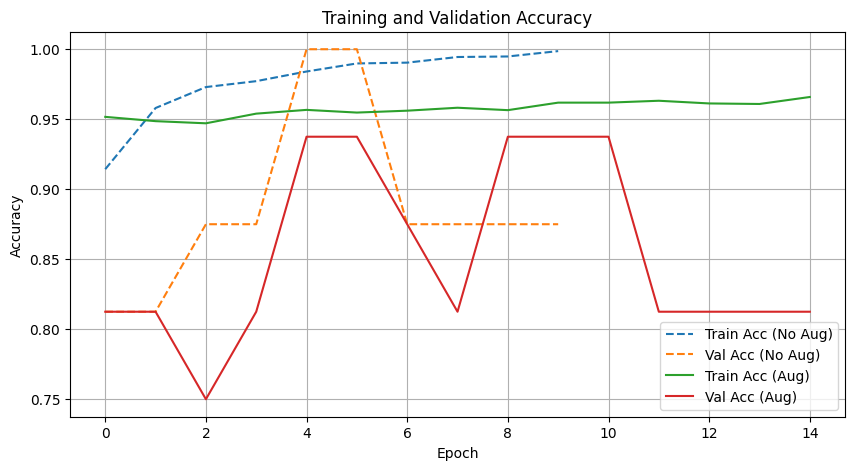

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Acc (No Aug)', linestyle='--')
plt.plot(history.history['val_accuracy'], label='Val Acc (No Aug)', linestyle='--')
plt.plot(history2.history['accuracy'], label='Train Acc (Aug)', linestyle='-')
plt.plot(history2.history['val_accuracy'], label='Val Acc (Aug)', linestyle='-')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("No Augmentation:")
print(f"  Train Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"  Val Accuracy:   {history.history['val_accuracy'][-1]:.4f}")
print()

print("With Augmentation:")
print(f"  Train Accuracy: {history2.history['accuracy'][-1]:.4f}")
print(f"  Val Accuracy:   {history2.history['val_accuracy'][-1]:.4f}")

No Augmentation:
  Train Accuracy: 0.9987
  Val Accuracy:   0.8750

With Augmentation:
  Train Accuracy: 0.9659
  Val Accuracy:   0.8125


In [ ]:
y_pred1 = (model.predict(X_test) > 0.5).astype("int").flatten()  # Assuming you recompiled same model
y_true = y_test_encode

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


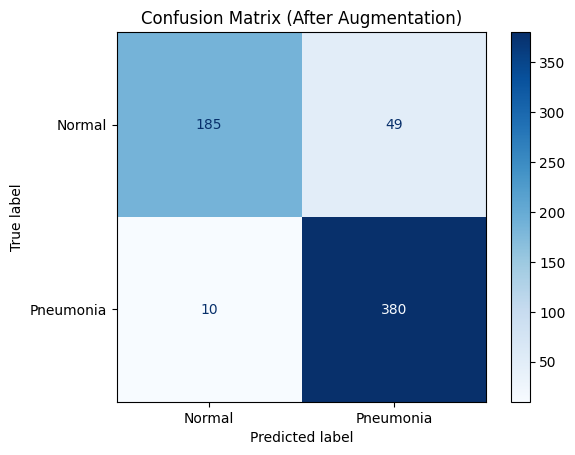

In [ ]:

cm = confusion_matrix(y_true, y_pred1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Pneumonia"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (After Augmentation)")
plt.show()

In [ ]:
print("Classification Report (With Augmentation):")
print(classification_report(y_true, y_pred1, target_names=["Normal", "Pneumonia"]))

Classification Report (With Augmentation):
              precision    recall  f1-score   support

      Normal       0.95      0.79      0.86       234
   Pneumonia       0.89      0.97      0.93       390

    accuracy                           0.91       624
   macro avg       0.92      0.88      0.90       624
weighted avg       0.91      0.91      0.90       624



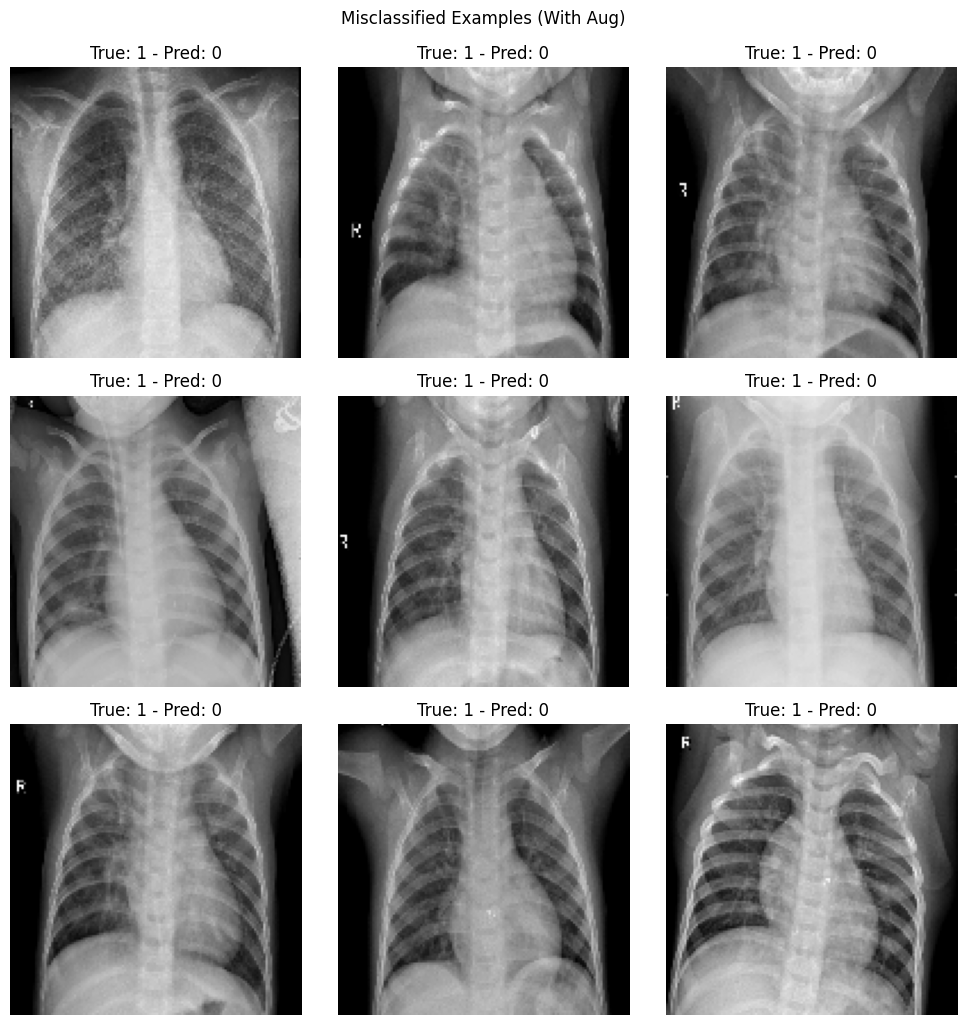

In [ ]:
wrong_indices = np.where(y_pred1 != y_true)[0]

plt.figure(figsize=(10, 10))
for i in range(9):
    idx = wrong_indices[i]
    plt.subplot(3, 3, i+1)
    plt.imshow(X_test[idx])
    plt.axis('off')
    plt.title(f"True: {y_true[idx]} - Pred: {y_pred1[idx]}")
plt.tight_layout()
plt.suptitle("Misclassified Examples (With Aug)", y=1.02)
plt.show()